In [1]:
# Created by Andrii Matsevytyi on 24.02.2025

# Main idea is to
# 1. Encode both images to latent space vectors
# 2. Interpolate these two vectors, using a blending mask
# 3. Convert the resulting vector back to the image

In [1]:
!pip install torch diffusers transformers accelerate safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 24.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
!gdown https://drive.google.com/uc?id=1teMMV7lxXotlzYqnt-a8-zn6nVYsYPFZ&export=download
!unzip frames.zip

Archive:  frames.zip
   creating: frames/
  inflating: __MACOSX/._frames       
  inflating: frames/.DS_Store        
  inflating: __MACOSX/frames/._.DS_Store  
   creating: frames/imgs/
  inflating: __MACOSX/frames/._imgs  
   creating: frames/bg/
   creating: frames/masks/
  inflating: __MACOSX/frames/._masks  
  inflating: frames/imgs/110020220086_01.png  
  inflating: __MACOSX/frames/imgs/._110020220086_01.png  
  inflating: frames/imgs/110020220079_01.png  
  inflating: __MACOSX/frames/imgs/._110020220079_01.png  
  inflating: frames/imgs/110020234383_01.png  
  inflating: __MACOSX/frames/imgs/._110020234383_01.png  
  inflating: frames/imgs/190605067703_01.png  
  inflating: __MACOSX/frames/imgs/._190605067703_01.png  
  inflating: frames/imgs/190605021125_01.png  
  inflating: __MACOSX/frames/imgs/._190605021125_01.png  
  inflating: frames/bg/.DS_Store     
  inflating: __MACOSX/frames/bg/._.DS_Store  
  inflating: frames/bg/bg_1.jpg      
  inflating: __MACOSX/frames/bg/._bg_1

In [3]:
import torch
from diffusers import StableDiffusionPipeline, AutoencoderKL
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [18]:
# Stable Diffusion and VAE (for latent encoding/decoding)

device = 'mps' if torch.backends.mps.is_available() else 'cpu' # NVIDIA suppost
device = 'cuda' if torch.cuda.is_available() else device # M1 Metal support

#vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-ema").to(device)

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

In [22]:
def encode_image(image):
    """Encodes an image into latent space."""
    image = image.resize((512, 512))  # Ensure correct size
    image = np.array(image).astype(np.float32) / 255.0
    image = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).to(device) * 2 - 1
    with torch.no_grad():
        latent = vae.encode(image).latent_dist.mode() * 0.18215 # or .sample()
    return latent

def decode_latent(latent):
    """Decodes a latent space tensor back to an image."""
    with torch.no_grad():
        image = vae.decode(latent / 0.18215).sample
    image = (image / 2 + 0.5).clamp(0, 1)
    image = (image[0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    return Image.fromarray(image)

def blend_latents(latent2, latent1, mask_img):
    """Blends two latent tensors using a mask in latent space."""

    # Convert mask to tensor and match latent size
    mask = mask_img.resize((latent1.shape[-1], latent1.shape[-2])).convert("L")
    mask = torch.tensor(np.array(mask) / 255.0, device=latent1.device).unsqueeze(0).unsqueeze(0)

    # Expand mask to match latent dimensions (assuming shape [1, C, H, W])
    mask = mask.expand_as(latent1)

    # Blend directly in latent space
    blended_latent = latent1 * (1 - mask) + latent2 * mask

    return blended_latent

def blend_images(dst_img, src_img, mask_img):
    """Blends two images using a mask in pixel space after decoding latents."""

    # Encode and decode both images
    latent1 = encode_image(src_img)
    latent2 = encode_image(dst_img)

    blended_latent = blend_latents(latent1, latent2, mask_img)
    blended_latent = blended_latent.to(dtype=torch.float32)

    blended_image = decode_latent(blended_latent)

    # Show result
    plt.imshow(blended_image)
    plt.axis("off")
    plt.show()

    return blended_image


In [20]:
src_img = Image.open("/content/frames/imgs/110020220079_01.png").convert("RGB").resize((512, 512))  # Source object
dst_img = Image.open("/content/frames/bg/bg_1.jpg").convert("RGB").resize((512, 512))
mask_img = Image.open("/content/frames/masks/110020220079_01.png").convert("L").resize((512, 512))  # Black & white mask

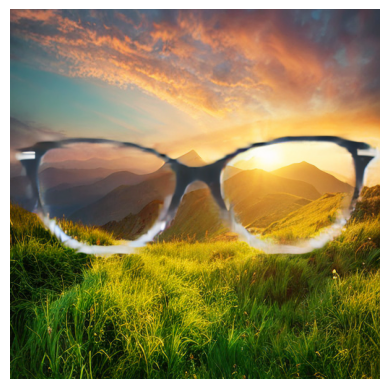

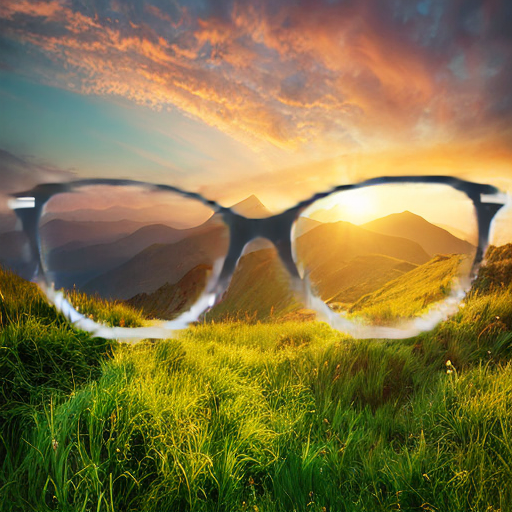

In [23]:
blend_images(dst_img, src_img, mask_img)